In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raw per-frame trajectory data: columns = #frame, resid, x, y, z, 4.5A_cutoff
RAW = '../../correctives/first_ns/'

# Time conversion: 200 ns = 20 000 frames  =>  1 frame = 10 ps = 0.01 ns
# Raw data covers frames 0–59999 corresponding to 400–1000 ns of simulation.
FRAME_TO_NS = 0.01
FRAME_OFFSET_NS = 0

# Residues to plot and a short descriptor for each
SELECTION = [
    ('SCL', 'LEU (hydrophobic)'),
    ('SCW', 'TRP (aromatic)'),
    ('GLYD', 'GLYD (polar)'),
    ('SCY', 'TYR (aromatic)'),
    #('SCD', 'ASP$^-$ (charged)'),
]

# Trajectory replicate to plot (1, 2 or 3)
TRAJ = 3
# Residue id to track
RESID = 10

In [17]:
def load_resid_z(acid, traj=1, resid=1):
    """Return (frame, z) arrays for the given resid from one trajectory file."""
    fpath = os.path.join(RAW, acid.lower(), f'{acid.lower()}_contacts_{traj}.dat')
    # Stream-read only the columns we need and filter by resid to keep memory low
    df = pd.read_csv(
        fpath, sep=r'\s+', engine='c',
        comment=None, header=0,
        usecols=[0, 1, 4],
        names=['frame', 'resid', 'z'],
        skiprows=1,
    )
    sub = df[df['resid'] == resid].sort_values('frame')
    return sub['frame'].to_numpy(), sub['z'].to_numpy()

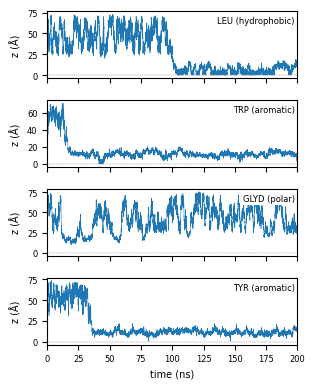

In [19]:
fig, axes = plt.subplots(
    len(SELECTION), 1, figsize=(8.26 / 2.54, 1.0 * len(SELECTION)),
    sharex=True,
)

for ax, (acid, label) in zip(axes, SELECTION):
    frames, z = load_resid_z(acid, traj=TRAJ, resid=RESID)
    t_ns = frames * FRAME_TO_NS + FRAME_OFFSET_NS
    ax.plot(t_ns, abs(z), lw=0.4)
    ax.axhline(0, color='gray', lw=0.3, linestyle='--')
    ax.set_ylabel('z (Å)', fontsize=7)
    ax.set_xlim(0, 200)
    ax.tick_params(axis='both', labelsize=6)
    ax.text(0.99, 0.92, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=6,
            bbox=dict(facecolor='white', edgecolor='none', pad=1))

axes[-1].set_xlabel('time (ns)', fontsize=7)
#fig.suptitle(f'z-coordinate of residue {RESID} (trajectory {TRAJ})', fontsize=7)
fig.tight_layout()
plt.savefig('../plot/check_eq_z_vs_time.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()